In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [2]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

Dimensiones del dataset:
(7267, 21)

Columnas:
Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
in

In [4]:
# eliminar duplicados
df = df.drop_duplicates()

# rellenar valores nulos
df = df.fillna(0)

print("Datos limpiados correctamente")

Datos limpiados correctamente


In [5]:
churn_counts = df["Churn"].value_counts()

print("Distribución de churn:")
print(churn_counts)

Distribución de churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


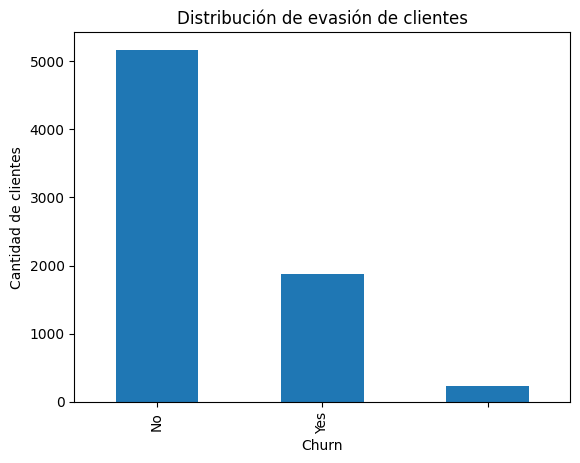

In [6]:
churn_counts.plot(kind="bar")

plt.title("Distribución de evasión de clientes")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")

plt.show()

In [9]:
contrato = df.groupby("Contract")["Churn"].value_counts().unstack()

contrato.plot(kind="bar", stacked=True)

plt.title("Churn por tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Clientes")

plt.show()

KeyError: 'Contract'

In [10]:
plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Distribución de cargos mensuales")
plt.xlabel("Cargo mensual")
plt.ylabel("Cantidad de clientes")

plt.show()

KeyError: 'MonthlyCharges'

Conclusiones del análisis

Los clientes con contratos mensuales presentan mayor churn.

Los contratos de largo plazo muestran menor evasión.

Los clientes con cargos mensuales más altos tienden a cancelar el servicio con mayor frecuencia.

Recomendaciones

Incentivar contratos anuales.

Crear beneficios de fidelización.

Revisar precios en planes con mayor cancelación.